# SPS MBB Dipole -- NCS Streaming Supercycle Analysis (200 GeV Extended)

**Measurement session:** `01_200_extended / 20260206_144537_SPS_MBB`
**Segment:** NCS
**Magnet:** MBB (normal dipole, m=1)
**Kn calibration:** AC compensation (cross-session from MBA, Dec 2025)
**Supercycle:** LHC_pilot -> MD1 (200 GeV) -> SFTPRO, x20 repetitions

| Section | Content |
|---------|----------|
| 1 | Configuration & imports |
| 2 | Kn calibration |
| 3 | Data loading & channel detection |
| 4 | Raw signals overview |
| 5 | cel/fed safety diagnostic |
| 6 | Plateau detection & current classification |
| 7 | Pipeline processing |
| 8 | Main field (B1) analysis |
| 9 | Transfer function B/I vs I |
| 10 | b2 (quadrupole) analysis |
| 11 | b3 (sextupole) analysis |
| 12 | Per-supercycle evolution |
| 13 | Summary & export |

---
## 1. Configuration & Imports

In [1]:
# === CONFIGURATION ===
SEGMENT = "NCS"

SESSION = "MBB/2026-02-06_supercycle/01_200_extended/20260206_144537_SPS_MBB"
MEAS_SUBDIR = "20260206_144559_MBB"
KN_CROSS_SESSION = "MBB/2025-12-12/CRMMMMH_AV-00000001/Kn_values_Seg_Main_A_AC.txt"

MAGNET_ORDER = 1          # dipole
R_REF = 0.02              # reference radius [m]
L_COIL = 0.47             # coil length [m]
SAMPLES_PER_TURN = 1024   # encoder samples per revolution

OPTIONS = ("dri", "rot", "cel", "fed")

MIN_B1_T = 1e-4           # minimum |B1| for normalization
PLATEAU_I_RANGE_MAX = 2.5 # block-averaged range threshold (A)
N_BLOCKS = 10             # blocks for range averaging

# Settling: last N turns per supercycle
N_LAST_TURNS_INJ = 18     # injection: keep last 18 of ~24
N_LAST_TURNS_HIGH = None   # flat-high: use all
MIN_SC_TURNS = 15         # minimum turns per supercycle (skip partial fragments)
N_SKIP_END_SC = 1         # trim last N turns per injection group (ramp contamination)

# Outlier removal
N_SIGMA_CLIP = 5           # MAD sigma clipping

print(f"SPS MBB Dipole -- {SEGMENT} Streaming Supercycle Analysis (200 GeV Extended)")
print("=" * 60)
print(f"  Session       : {SESSION}")
print(f"  Segment       : {SEGMENT}")
print(f"  Magnet order  : {MAGNET_ORDER} (dipole)")
print(f"  R_ref         : {R_REF} m")
print(f"  Samples/turn  : {SAMPLES_PER_TURN}")
print(f"  Options       : {OPTIONS}")
print(f"  Plateau thresh: {PLATEAU_I_RANGE_MAX} A")

SPS MBB Dipole -- NCS Streaming Supercycle Analysis (200 GeV Extended)
  Session       : 2026_02_06/01_200_extended/20260206_144537_SPS_MBB
  Segment       : NCS
  Magnet order  : 1 (dipole)
  R_ref         : 0.02 m
  Samples/turn  : 1024
  Options       : ('dri', 'rot', 'cel', 'fed')
  Plateau thresh: 2.5 A


In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

repo_root = Path("../..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
    mad_sigma_clip,
    FdiTransitionCheck,
    diagnose_fdi_transitions,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

SESSION_DIR = REPO_ROOT / "measurements" / SESSION
RUN_DIR = SESSION_DIR / MEAS_SUBDIR
KN_PATH = REPO_ROOT / "measurements" / KN_CROSS_SESSION
assert KN_PATH.exists(), f"Kn file not found: {KN_PATH}"

print(f"Repo root   : {REPO_ROOT}")
print(f"Session dir : {SESSION_DIR}")
print(f"Run dir     : {RUN_DIR}")
print(f"Kn file     : {KN_PATH}")
print("Imports ready.")

Repo root   : C:\Users\albellel\python-projects\rotating-coil-analyzer
Session dir : C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\2026_02_06\01_200_extended\20260206_144537_SPS_MBB
Run dir     : C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\2026_02_06\01_200_extended\20260206_144537_SPS_MBB\20260206_144559_MBB
Kn file     : C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\20251212_171026_SPS_MBA\CRMMMMH_AV-00000001\Kn_values_Seg_Main_A_AC.txt
Imports ready.


---
## 2. Kn Calibration (AC Compensation)

In [3]:
kn = load_segment_kn_txt(str(KN_PATH))
H = len(kn.orders)
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER

print(f"Kn: {H} harmonics from {KN_PATH.name}")
print(f"  Orders: {list(kn.orders)}")

kn_abs_n1 = abs(kn.kn_abs[0])
kn_cmp_n1 = abs(kn.kn_cmp[0])
ratio_n1 = kn_abs_n1 / max(kn_cmp_n1, 1e-30)

print(f"\n  |Kn_abs(n=1)| = {kn_abs_n1:.6e}")
print(f"  |Kn_cmp(n=1)| = {kn_cmp_n1:.6e}")
print(f"  Abs/Cmp suppression ratio (n=1): {ratio_n1:.0f}x")

Kn: 15 harmonics from Kn_values_Seg_Main_A_AC.txt
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

  |Kn_abs(n=1)| = 1.154364e-01
  |Kn_cmp(n=1)| = 5.695530e-06
  Abs/Cmp suppression ratio (n=1): 20268x


---
## 3. Data Loading & Channel Detection

In [4]:
FILE_PAT = re.compile(
    r"Run_(\d+)_I_([\d.]+)A_(N?CS)_raw_measurement_data\.txt$"
)

ncs_files = []
for f in sorted(RUN_DIR.iterdir()):
    match = FILE_PAT.search(f.name)
    if match and match.group(3) == SEGMENT:
        ncs_files.append(f)
assert ncs_files, f"No {SEGMENT} raw files found in {RUN_DIR}"
raw_file = ncs_files[0]

raw = np.loadtxt(raw_file)
n_turns = raw.shape[0] // Ns
n_keep = n_turns * Ns
ncols = raw.shape[1]

print(f"Raw file: {raw_file.name}")
print(f"Shape: {raw.shape} -> {n_turns} turns, {ncols} columns")
print(f"Time span: {raw[-1,0] - raw[0,0]:.1f} s ({(raw[-1,0] - raw[0,0])/60:.1f} min)")

# Reshape
t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
flux_col1 = raw[:n_keep, 1].reshape(n_turns, Ns)
flux_col2 = raw[:n_keep, 2].reshape(n_turns, Ns)
I_all = raw[:n_keep, 3].reshape(n_turns, Ns)
has_voltage = ncols > 4
if has_voltage:
    V_all = raw[:n_keep, 4].reshape(n_turns, Ns)

# Auto-detect channel swap
I_mean_quick = I_all.mean(axis=1)
best_turn = np.argmax(np.abs(I_mean_quick))
r1 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 1])
r2 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 2])
SWAP_FLUX = (r2 > r1)

if SWAP_FLUX:
    flux_abs_all = flux_col2
    flux_cmp_all = flux_col1
    print("  (flux columns swapped: col2=abs, col1=cmp)")
else:
    flux_abs_all = flux_col1
    flux_cmp_all = flux_col2

print(f"\nColumn assignment:")
print(f"  col 0  -> time (s)")
print(f"  col {'2' if SWAP_FLUX else '1'}  -> flux abs (range={max(r1,r2):.4e})")
print(f"  col {'1' if SWAP_FLUX else '2'}  -> flux cmp (range={min(r1,r2):.4e})")
print(f"  col 3  -> current")
if has_voltage:
    print(f"  col 4  -> voltage")

Raw file: 20260206_144559_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
Shape: (1086464, 5) -> 1061 turns, 5 columns
Time span: 1061.0 s (17.7 min)

Column assignment:
  col 0  -> time (s)
  col 1  -> flux abs (range=2.9374e-03)
  col 2  -> flux cmp (range=3.6848e-06)
  col 3  -> current
  col 4  -> voltage


---
## 4. Raw Signals Overview

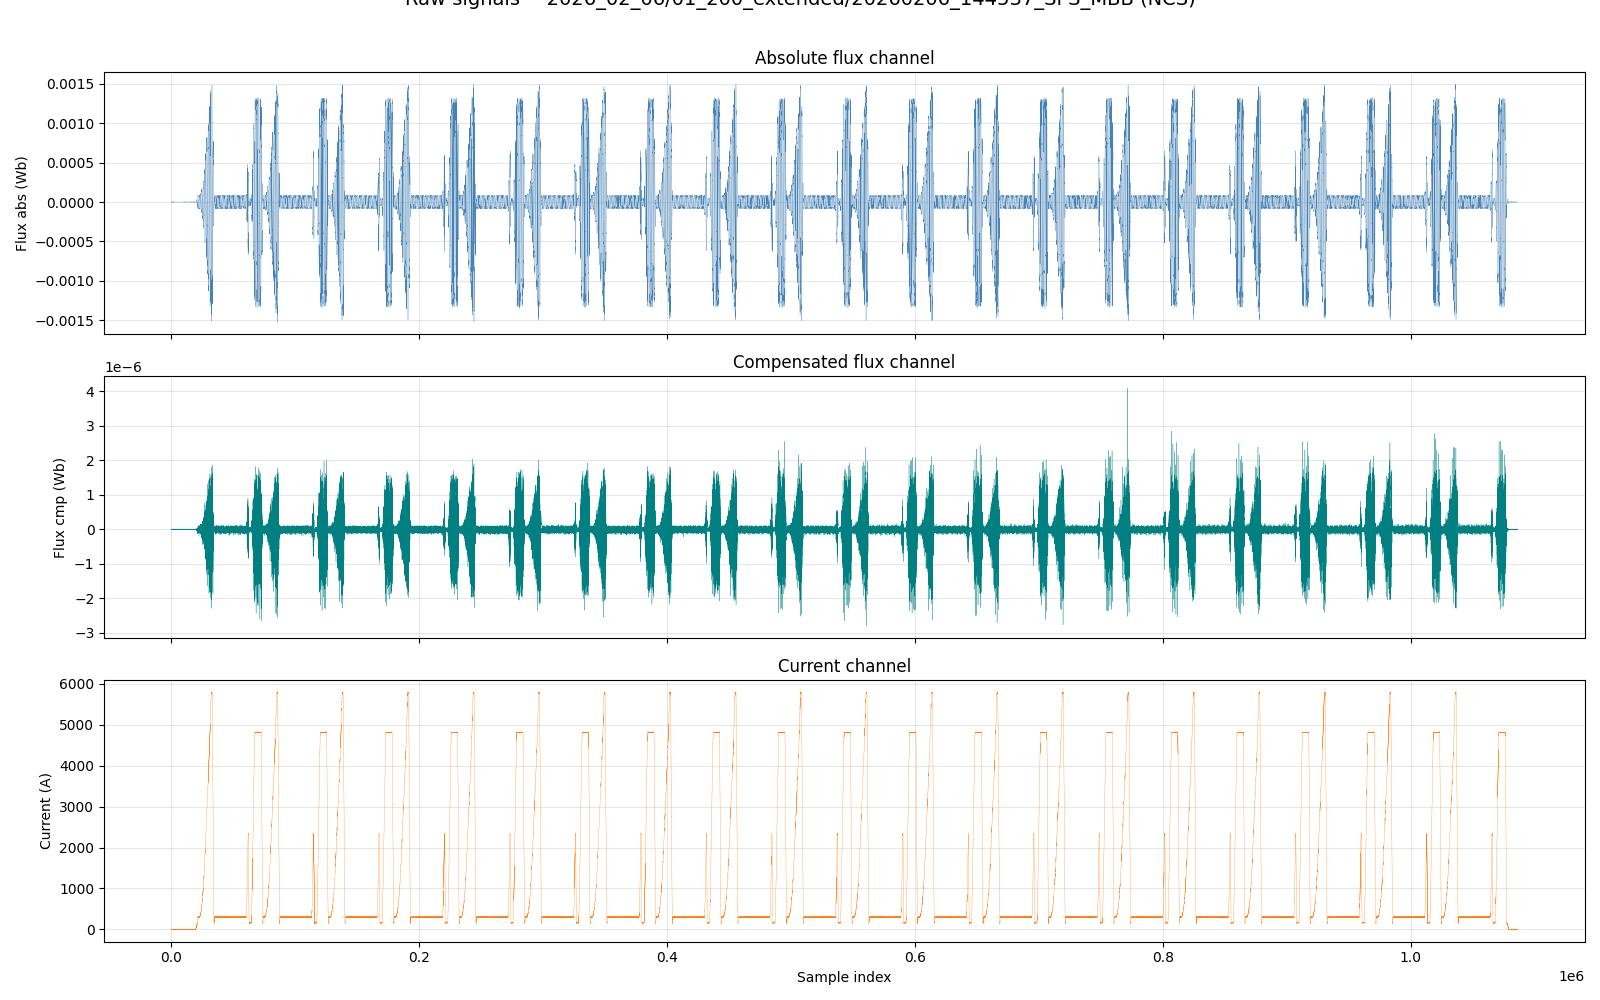

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

x = np.arange(n_keep)
ax = axes[0]
ax.plot(x, raw[:n_keep, 1 if not SWAP_FLUX else 2], linewidth=0.2, color="steelblue")
ax.set_ylabel("Flux abs (Wb)")
ax.set_title("Absolute flux channel")

ax = axes[1]
ax.plot(x, raw[:n_keep, 2 if not SWAP_FLUX else 1], linewidth=0.2, color="teal")
ax.set_ylabel("Flux cmp (Wb)")
ax.set_title("Compensated flux channel")

ax = axes[2]
ax.plot(x, raw[:n_keep, 3], linewidth=0.2, color="tab:orange")
ax.set_ylabel("Current (A)")
ax.set_title("Current channel")

axes[-1].set_xlabel("Sample index")
fig.suptitle(f"Raw signals -- {SESSION} ({SEGMENT})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on high-current turns to check whether the
centre-location + feeddown correction is safe for this data.

In [6]:
I_mean = I_all.mean(axis=1)
hi_mask = np.abs(I_mean) > 4000
if hi_mask.sum() < 5:
    hi_mask = np.abs(I_mean) > np.percentile(np.abs(I_mean), 90)

n_diag = min(100, int(hi_mask.sum()))
hi_idx = np.where(hi_mask)[0][:n_diag]

diag = diagnose_cel_fed(
    flux_abs_all[hi_idx], flux_cmp_all[hi_idx],
    t_all[hi_idx], I_all[hi_idx],
    kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic ({n_diag} high-I turns):")
print(f"  Recommendation: {diag.recommendation}")
print(f"  {diag.reason}")
Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {Bd:.4e} T")

if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 high-I turns):
  Recommendation: UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.0514, max 0.0930). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.0994e-02 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 6. Plateau Detection & Current Classification

  injection   :  488 turns, I = 300.9 +/- 0.2 A
  flat-high   :   74 turns, I = 4814.5 +/- 1.8 A
  ramp        :  462 turns

Total: 1061 turns, 599 plateau

Injection groups (supercycles): 20
Flat-high groups: 20


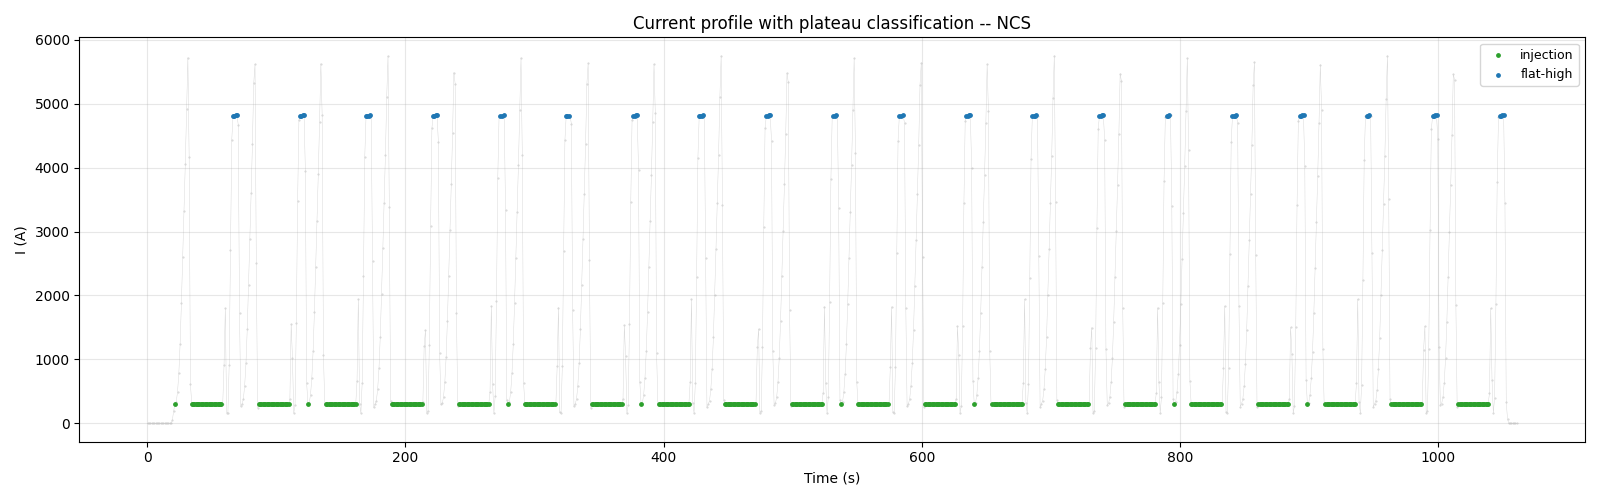

In [7]:
I_mean = I_all.mean(axis=1)
t_mean = t_all.mean(axis=1)
I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)

plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
is_plateau = plateau_info["is_plateau"]

turn_label = np.array(["ramp"] * n_turns, dtype=object)
for i in range(n_turns):
    if is_plateau[i]:
        turn_label[i] = classify_current(I_mean[i])

for lab in ["injection", "flat-mid", "flat-high"]:
    mask = turn_label == lab
    n = mask.sum()
    if n > 0:
        print(f"  {lab:12s}: {n:4d} turns, I = {I_mean[mask].mean():.1f} +/- {I_mean[mask].std():.1f} A")
print(f"  {'ramp':12s}: {(turn_label == 'ramp').sum():4d} turns")
print(f"\nTotal: {n_turns} turns, {is_plateau.sum()} plateau")

inj_groups = find_contiguous_groups(turn_label == "injection", min_length=2)
fh_groups = find_contiguous_groups(turn_label == "flat-high", min_length=2)
print(f"\nInjection groups (supercycles): {len(inj_groups)}")
print(f"Flat-high groups: {len(fh_groups)}")

# Current profile plot
fig, ax = plt.subplots(figsize=(16, 5))
label_colors = {"injection": "tab:green", "flat-mid": "tab:purple", "flat-high": "tab:blue"}
ax.plot(t_mean, I_mean, ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
for lab, col in label_colors.items():
    mask = turn_label == lab
    idx = np.where(mask)[0]
    if len(idx) > 0:
        ax.scatter(t_mean[idx], I_mean[idx], s=6, color=col, zorder=2, label=lab)
ax.set_xlabel("Time (s)")
ax.set_ylabel("I (A)")
ax.set_title(f"Current profile with plateau classification -- {SEGMENT}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### FDI Stuck-Channel Diagnostic

In [8]:
# --- FDI stuck-channel diagnostic ---
_plat_groups = find_contiguous_groups(is_plateau, min_length=2)
_run_info_for_fdi = [
    {"run_id": i, "start": s, "end": e, "I_nom": float(I_mean[s:e].mean())}
    for i, (s, e) in enumerate(_plat_groups)
]
fdi_checks = diagnose_fdi_transitions(
    flux_abs_all, I_mean, _run_info_for_fdi, n_boundary=10,
)

# Summary table
fdi_stuck_run_ids: set[int] = set()
print(f"{"From":>6s} {"To":>6s}  {"ΔI":>7s}  {"Gap":>4s}  "
      f"{"flux_bef":>9s} {"flux_aft0":>9s} {"flux_set":>9s}  "
      f"{"ratio":>6s}  Status")
print("-" * 82)
for c in fdi_checks:
    tag = {"OK": "  OK", "PARTIAL": " PART", "STUCK": "STUCK"}[c.severity]
    print(f"{c.run_before:6d} {c.run_after:6d}  {c.delta_I:+7.1f}  {c.n_gap_turns:4d}  "
          f"{c.flux_rng_before:9.1f} {c.flux_rng_after_start:9.1f} {c.flux_rng_after_settled:9.1f}  "
          f"{c.response_ratio:+6.2f}  {tag}")
    if c.is_stuck:
        fdi_stuck_run_ids.add(c.run_after)

if fdi_stuck_run_ids:
    print()
    print(f"⚠️  WARNING: {len(fdi_stuck_run_ids)} run(s) follow a STUCK FDI transition!")
    print(f"   Affected run IDs: {sorted(fdi_stuck_run_ids)}")
else:
    print()
    print(f"✔ All FDI transitions look healthy ({len(fdi_checks)} checked, "
          f"{sum(1 for c in fdi_checks if c.severity == "OK")} OK).")


  From     To       ΔI   Gap   flux_bef flux_aft0  flux_set   ratio  Status
----------------------------------------------------------------------------------
     0      1   +300.9    15        0.0       0.0       0.0   +1.00    OK
     1      2  +4512.7     8        0.0       0.0       0.0   +1.00    OK
     2      3  -4512.7    16        0.0       0.0       0.0   +1.00    OK
     3      4  +4513.2     8        0.0       0.0       0.0   +1.00    OK
     4      5  -4513.2    16        0.0       0.0       0.0   +1.00    OK
     5      6  +4512.3     7        0.0       0.0       0.0   +1.00    OK
     6      7  -4512.3    16        0.0       0.0       0.0   +1.00    OK
     7      8  +4513.0     8        0.0       0.0       0.0   +1.00    OK
     8      9  -4513.0    16        0.0       0.0       0.0   +1.00    OK
     9     10  +4512.1     8        0.0       0.0       0.0   +1.00    OK
    10     11  -4512.2    17        0.0       0.0       0.0   +1.00    OK
    11     12  +4511.8     

---
## 7. Pipeline Processing

In [9]:
ANALYSIS_LABELS = {"injection", "flat-mid", "flat-high"}
is_analysis = np.array([l in ANALYSIS_LABELS for l in turn_label])
plateau_indices = np.where(is_analysis)[0]
print(f"Processing {len(plateau_indices)} plateau turns through Kn pipeline...")

result, C_merged, C_units, ok_main = process_kn_pipeline(
    flux_abs_turns=flux_abs_all[plateau_indices],
    flux_cmp_turns=flux_cmp_all[plateau_indices],
    t_turns=t_all[plateau_indices],
    I_turns=I_all[plateau_indices],
    kn=kn, r_ref=R_REF, magnet_order=m,
    options=OPTIONS, min_b1_T=MIN_B1_T,
)

extra = [
    {
        "global_turn": int(plateau_indices[t]),
        "label": str(turn_label[plateau_indices[t]]),
        "I_range_A": float(I_range[plateau_indices[t]]),
    }
    for t in range(len(plateau_indices))
]

rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
df = pd.DataFrame(rows)

# Group injection turns by supercycle
df["sc_idx"] = -1
settled_idx = []

for gi, (gs, ge) in enumerate(inj_groups):
    group_globals = set(range(gs, ge + 1))
    gmask = df["global_turn"].isin(group_globals) & (df["label"] == "injection")
    df.loc[gmask, "sc_idx"] = gi
    group_rows = df.index[gmask]
    if len(group_rows) < MIN_SC_TURNS:
        continue  # skip partial supercycle fragments
    if N_SKIP_END_SC > 0 and len(group_rows) > N_SKIP_END_SC + 2:
        group_rows = group_rows[:-N_SKIP_END_SC]
    if N_LAST_TURNS_INJ is not None and len(group_rows) > N_LAST_TURNS_INJ:
        settled_idx.extend(group_rows[-N_LAST_TURNS_INJ:])
    else:
        settled_idx.extend(group_rows)

for gi, (gs, ge) in enumerate(fh_groups):
    group_globals = set(range(gs, ge + 1))
    gmask = df["global_turn"].isin(group_globals) & (df["label"] == "flat-high")
    df.loc[gmask, "sc_idx"] = gi
    group_rows = df.index[gmask]
    if N_LAST_TURNS_HIGH is not None and len(group_rows) > N_LAST_TURNS_HIGH:
        settled_idx.extend(group_rows[-N_LAST_TURNS_HIGH:])
    else:
        settled_idx.extend(group_rows)

df_settled = df.loc[sorted(settled_idx)].copy()

n_before = len(df_settled)
df_settled, clip_info = mad_sigma_clip(df_settled, "B1_T", N_SIGMA_CLIP, label_col="label")
n_clipped = n_before - len(df_settled)
if n_clipped > 0:
    print(f"  Sigma clip ({N_SIGMA_CLIP} MAD sigma): removed {n_clipped} turns ({clip_info})")

print(f"\nAll plateau turns: {len(df)}")
print(f"Settled turns (after sigma clip): {len(df_settled)}")
for lab in ["injection", "flat-high"]:
    n_all = len(df[df["label"] == lab])
    n_set = len(df_settled[df_settled["label"] == lab])
    print(f"  {lab:12s}: {n_all} -> {n_set}")
print(f"\nok_main: {df['ok_main'].sum()} / {len(df)}")
print(f"Harmonics: n=1..{H}")

Processing 562 plateau turns through Kn pipeline...

All plateau turns: 562
Settled turns (after sigma clip): 432
  injection   : 488 -> 360
  flat-high   : 74 -> 72

ok_main: 562 / 562
Harmonics: n=1..15


---
## 8. Main Field (B1) Analysis

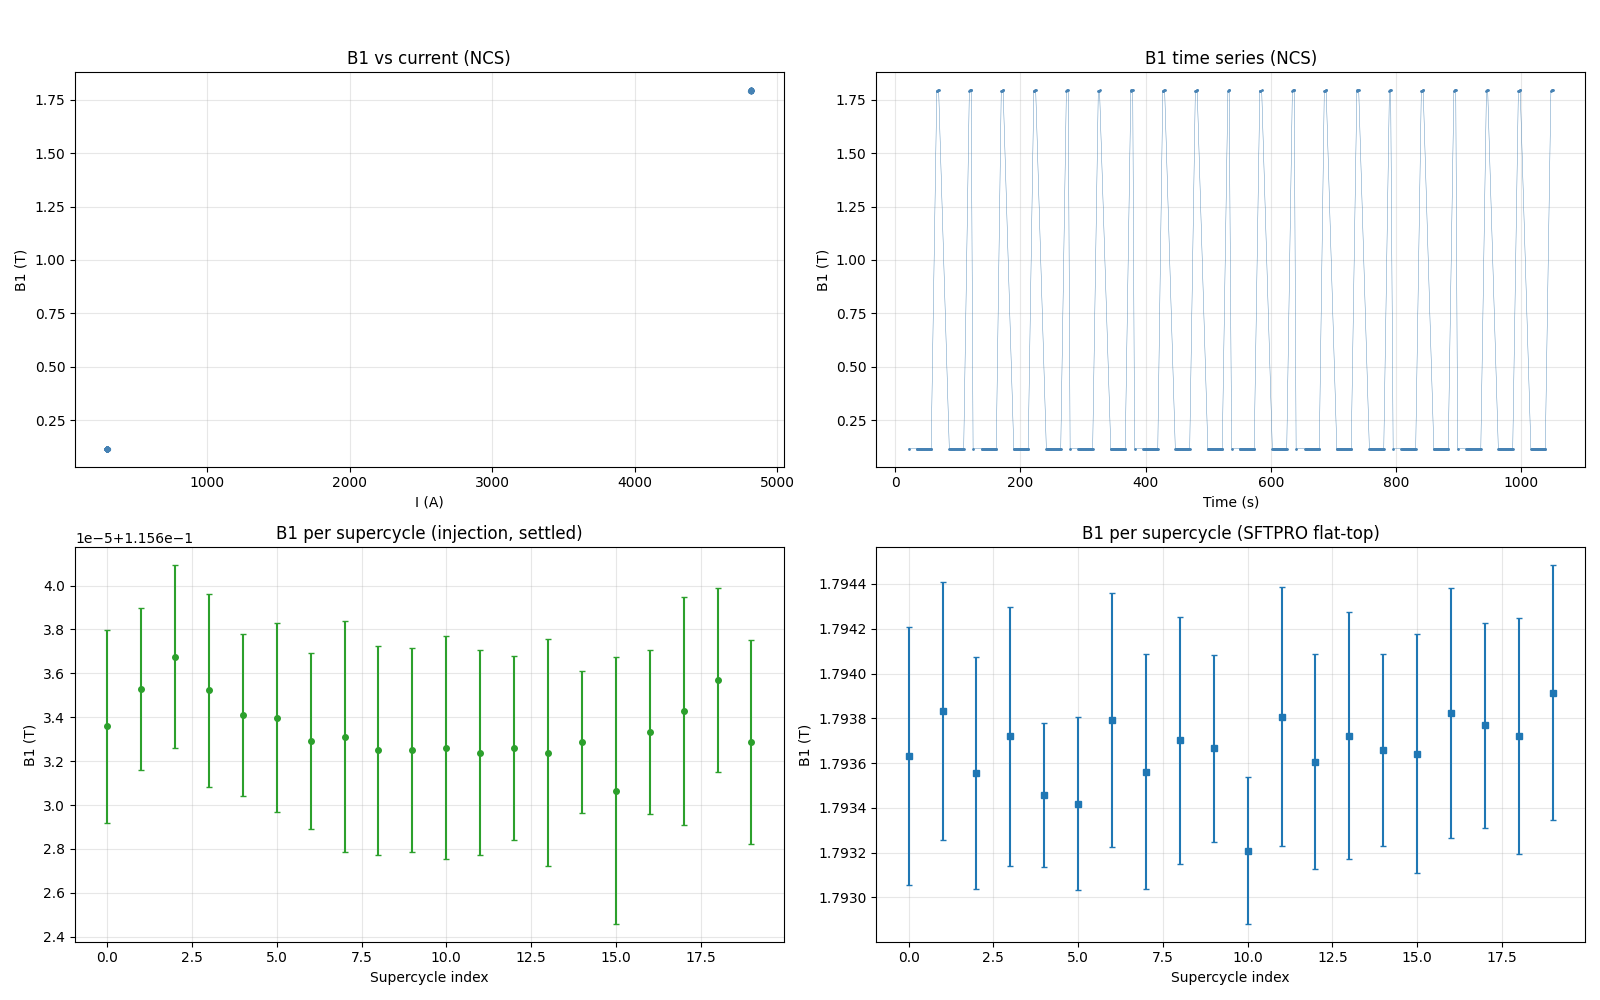


B1 per operating point (settled turns):
       Label     N     mean (T)      std (T)
---------------------------------------------
   injection   360    +0.115633     0.000005
   flat-high    72    +1.793681     0.000472


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ok = df["ok_main"]
ax = axes[0, 0]
ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "B1_T"], s=8, alpha=0.5, color="steelblue")
ax.set_xlabel("I (A)"); ax.set_ylabel("B1 (T)")
ax.set_title(f"B1 vs current ({SEGMENT})")

ax = axes[0, 1]
ax.plot(df.loc[ok, "time_s"].values, df.loc[ok, "B1_T"].values,
        ".-", markersize=2, linewidth=0.3, color="steelblue")
ax.set_xlabel("Time (s)"); ax.set_ylabel("B1 (T)")
ax.set_title(f"B1 time series ({SEGMENT})")

ax = axes[1, 0]
inj_set = df_settled[(df_settled["label"] == "injection") & df_settled["ok_main"]]
if len(inj_set) > 0:
    sc_b1 = inj_set.groupby("sc_idx")["B1_T"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b1["sc_idx"], sc_b1["mean"], yerr=sc_b1["std"],
                fmt="o", markersize=4, capsize=2, color="tab:green")
ax.set_xlabel("Supercycle index"); ax.set_ylabel("B1 (T)")
ax.set_title("B1 per supercycle (injection, settled)")

ax = axes[1, 1]
fh_set = df_settled[(df_settled["label"] == "flat-high") & df_settled["ok_main"]]
if len(fh_set) > 0:
    sc_b1_fh = fh_set.groupby("sc_idx")["B1_T"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b1_fh["sc_idx"], sc_b1_fh["mean"], yerr=sc_b1_fh["std"],
                fmt="s", markersize=4, capsize=2, color="tab:blue")
ax.set_xlabel("Supercycle index"); ax.set_ylabel("B1 (T)")
ax.set_title("B1 per supercycle (SFTPRO flat-top)")

fig.suptitle(f"Main Field (B1) -- {SESSION} ({SEGMENT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nB1 per operating point (settled turns):")
print(f"{'Label':>12s} {'N':>5s} {'mean (T)':>12s} {'std (T)':>12s}")
print("-" * 45)
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        print(f"{lab:>12s} {len(sub):5d} {sub['B1_T'].mean():+12.6f} {sub['B1_T'].std():12.6f}")

---
## 9. Transfer Function B/I vs I

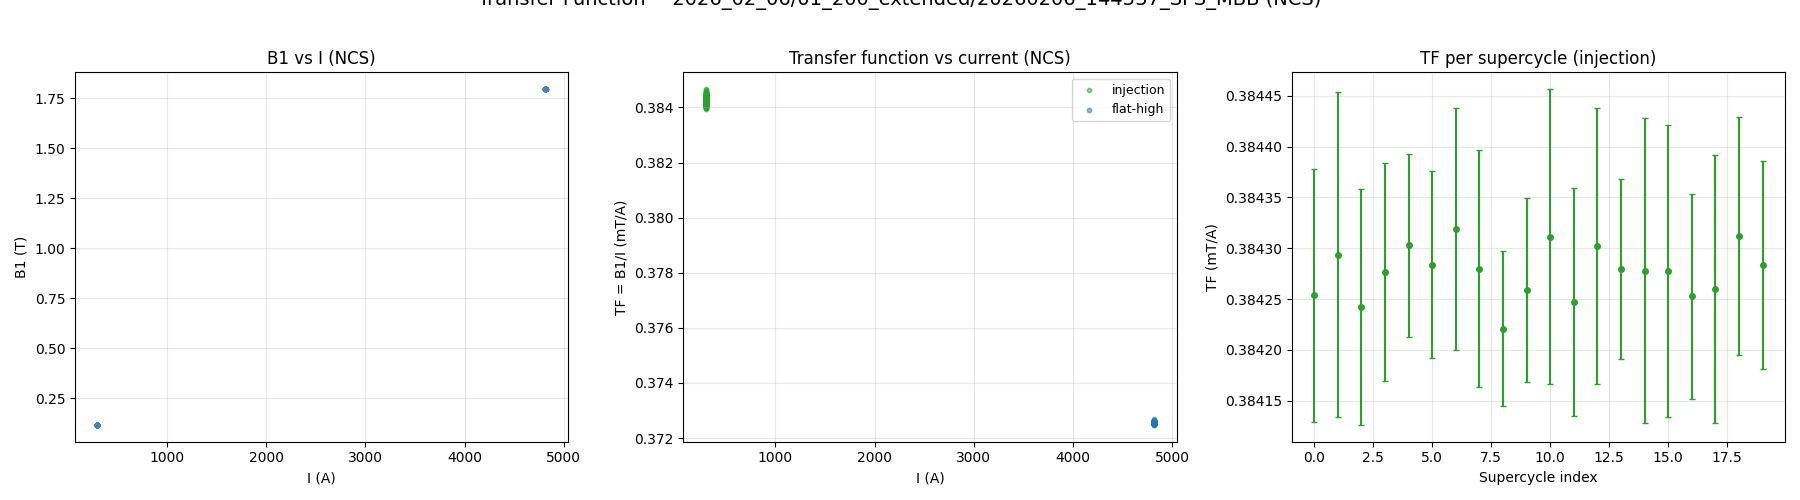


Transfer function per operating point (settled turns):
       Label     N   TF mean (mT/A)    TF std (mT/A)
-------------------------------------------------------
   injection   360         0.384277         0.000118
   flat-high    72         0.372561         0.000044


In [11]:
ok_tf = df_settled["ok_main"] & (df_settled["I_mean_A"].abs() > 10)
df_tf = df_settled[ok_tf].copy()
df_tf["TF_mTpA"] = df_tf["B1_T"] / df_tf["I_mean_A"] * 1e3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(df_tf["I_mean_A"], df_tf["B1_T"], s=8, alpha=0.5, color="steelblue")
ax.set_xlabel("I (A)"); ax.set_ylabel("B1 (T)"); ax.set_title(f"B1 vs I ({SEGMENT})")

ax = axes[1]
for lab, col in [("injection", "tab:green"), ("flat-high", "tab:blue")]:
    sub = df_tf[df_tf["label"] == lab]
    if len(sub) > 0:
        ax.scatter(sub["I_mean_A"], sub["TF_mTpA"], s=10, alpha=0.5, color=col, label=lab)
ax.set_xlabel("I (A)"); ax.set_ylabel("TF = B1/I (mT/A)")
ax.set_title(f"Transfer function vs current ({SEGMENT})"); ax.legend(fontsize=9)

ax = axes[2]
inj_tf = df_tf[df_tf["label"] == "injection"]
if len(inj_tf) > 0:
    sc_tf = inj_tf.groupby("sc_idx")["TF_mTpA"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_tf["sc_idx"], sc_tf["mean"], yerr=sc_tf["std"],
                fmt="o", markersize=4, capsize=2, color="tab:green")
ax.set_xlabel("Supercycle index"); ax.set_ylabel("TF (mT/A)")
ax.set_title("TF per supercycle (injection)")

fig.suptitle(f"Transfer Function -- {SESSION} ({SEGMENT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nTransfer function per operating point (settled turns):")
print(f"{'Label':>12s} {'N':>5s} {'TF mean (mT/A)':>16s} {'TF std (mT/A)':>16s}")
print("-" * 55)
for lab in ["injection", "flat-high"]:
    sub = df_tf[df_tf["label"] == lab]
    if len(sub) > 0:
        print(f"{lab:>12s} {len(sub):5d} {sub['TF_mTpA'].mean():16.6f} {sub['TF_mTpA'].std():16.6f}")

---
## 10. b2 (Quadrupole) Analysis

b2 is the first allowed harmonic error for a dipole.

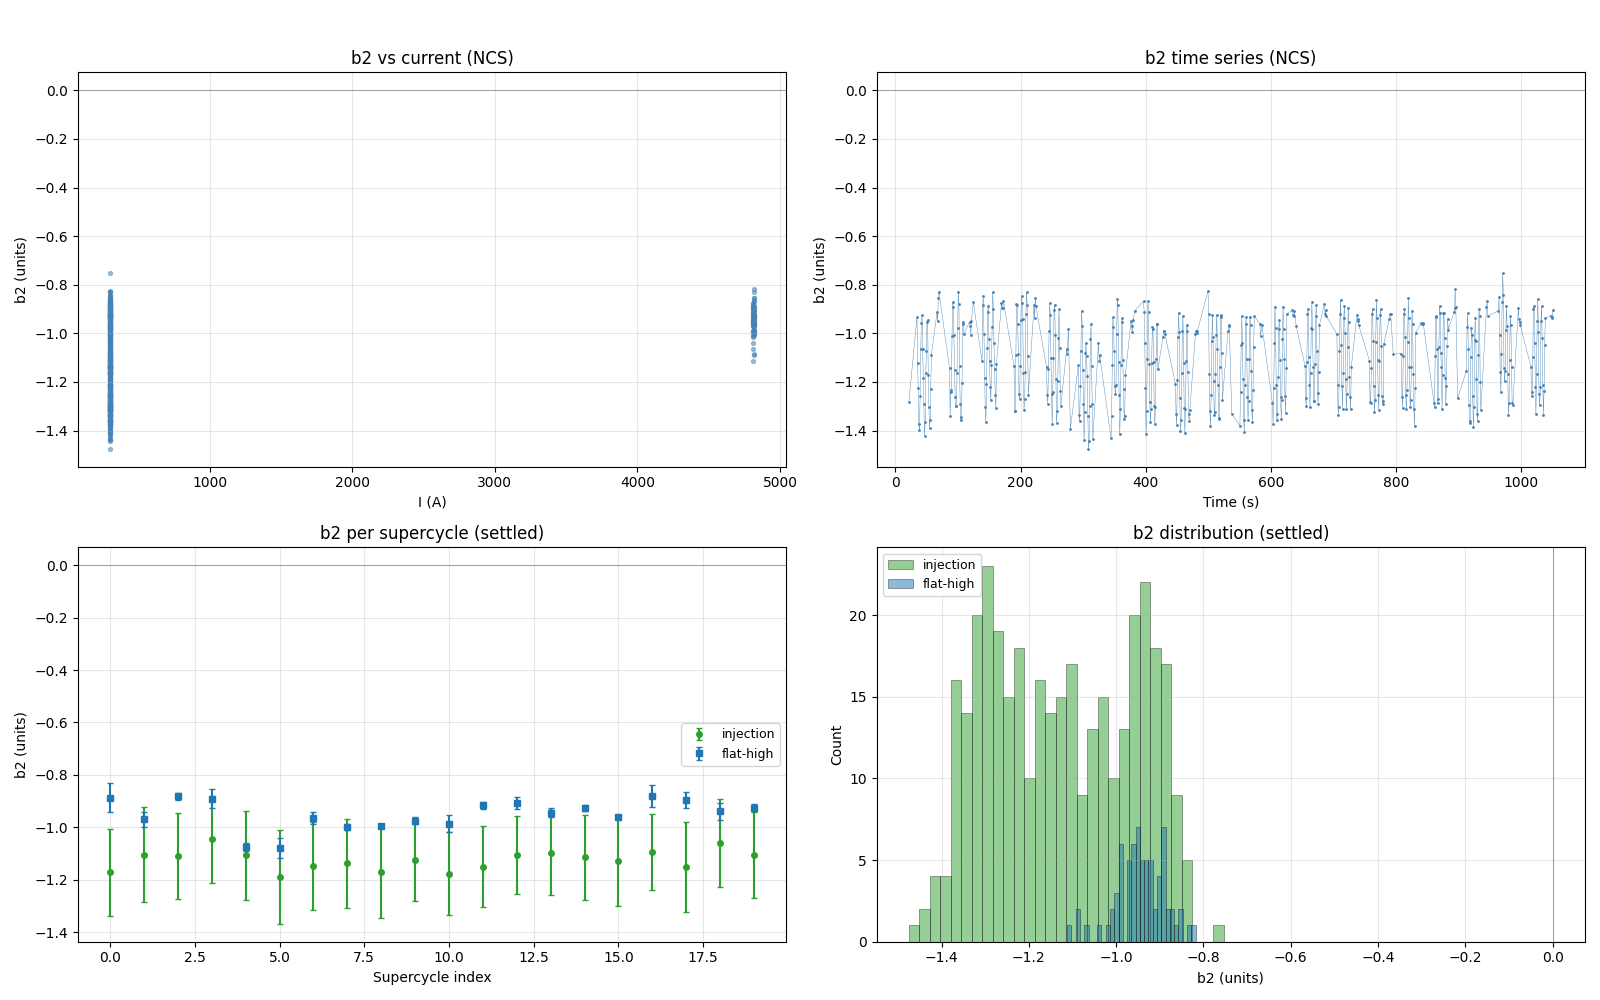


b2 per operating point (settled turns):
       Label     N       mean        std     median
--------------------------------------------------
   injection   360    -1.1251     0.1648    -1.1343
   flat-high    72    -0.9445     0.0572    -0.9421


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ok_nz = df["ok_main"]
b2_all = df.loc[ok_nz, "b2_units"].values

ax = axes[0, 0]
ax.scatter(df.loc[ok_nz, "I_mean_A"], b2_all, s=8, alpha=0.5, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("I (A)"); ax.set_ylabel("b2 (units)")
ax.set_title(f"b2 vs current ({SEGMENT})")

ax = axes[0, 1]
ax.plot(df.loc[ok_nz, "time_s"].values, b2_all, ".-", markersize=2, linewidth=0.3, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Time (s)"); ax.set_ylabel("b2 (units)")
ax.set_title(f"b2 time series ({SEGMENT})")

ax = axes[1, 0]
inj_set = df_settled[(df_settled["label"] == "injection") & df_settled["ok_main"]]
if len(inj_set) > 0:
    sc_b2 = inj_set.groupby("sc_idx")["b2_units"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b2["sc_idx"], sc_b2["mean"], yerr=sc_b2["std"],
                fmt="o", markersize=4, capsize=2, color="tab:green", label="injection")
fh_set = df_settled[(df_settled["label"] == "flat-high") & df_settled["ok_main"]]
if len(fh_set) > 0:
    sc_b2_fh = fh_set.groupby("sc_idx")["b2_units"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b2_fh["sc_idx"], sc_b2_fh["mean"], yerr=sc_b2_fh["std"],
                fmt="s", markersize=4, capsize=2, color="tab:blue", label="flat-high")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Supercycle index"); ax.set_ylabel("b2 (units)")
ax.set_title("b2 per supercycle (settled)"); ax.legend(fontsize=9)

ax = axes[1, 1]
for lab, col in [("injection", "tab:green"), ("flat-high", "tab:blue")]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        ax.hist(sub["b2_units"], bins=30, alpha=0.5, color=col, label=lab, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("b2 (units)"); ax.set_ylabel("Count")
ax.set_title("b2 distribution (settled)"); ax.legend(fontsize=9)

fig.suptitle(f"b2 (Quadrupole) -- {SESSION} ({SEGMENT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nb2 per operating point (settled turns):")
print(f"{'Label':>12s} {'N':>5s} {'mean':>10s} {'std':>10s} {'median':>10s}")
print("-" * 50)
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        v = sub["b2_units"].values
        print(f"{lab:>12s} {len(sub):5d} {v.mean():+10.4f} {v.std():10.4f} {np.median(v):+10.4f}")

---
## 11. b3 (Sextupole) Analysis

b3 is the first non-allowed harmonic for an ideal dipole and a key quality indicator.

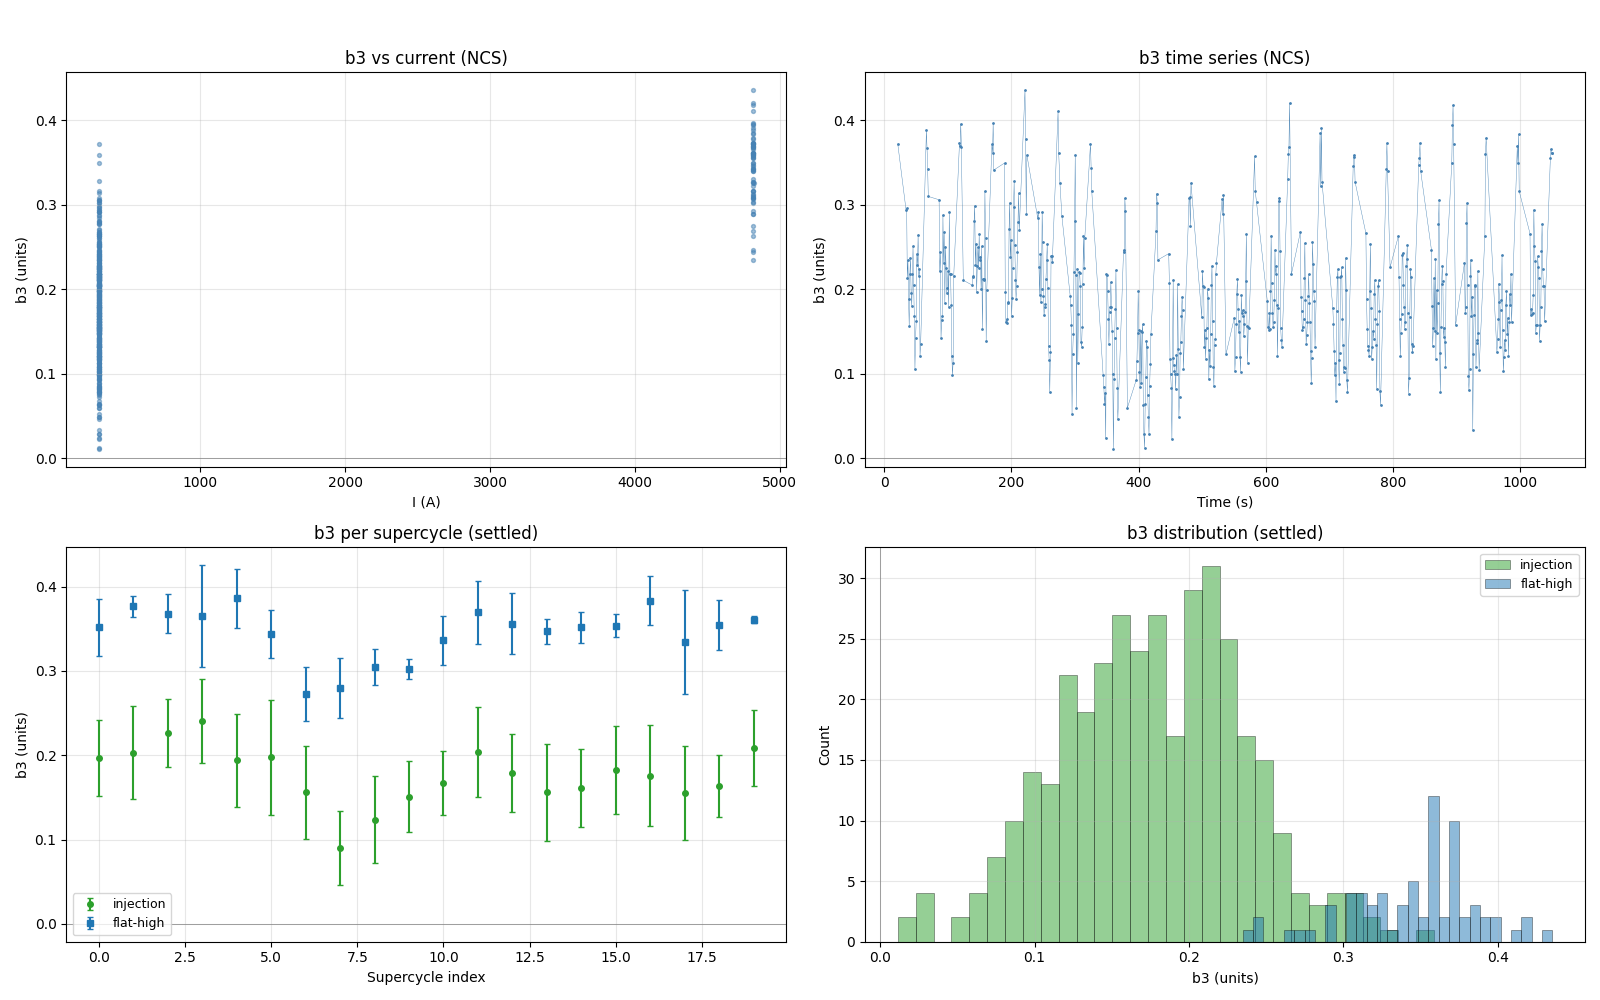


b3 per operating point (settled turns):
       Label     N       mean        std     median
--------------------------------------------------
   injection   360    +0.1766     0.0597    +0.1785
   flat-high    72    +0.3447     0.0415    +0.3554


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ok_nz = df["ok_main"]
b3_all = df.loc[ok_nz, "b3_units"].values

ax = axes[0, 0]
ax.scatter(df.loc[ok_nz, "I_mean_A"], b3_all, s=8, alpha=0.5, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("I (A)"); ax.set_ylabel("b3 (units)")
ax.set_title(f"b3 vs current ({SEGMENT})")

ax = axes[0, 1]
ax.plot(df.loc[ok_nz, "time_s"].values, b3_all, ".-", markersize=2, linewidth=0.3, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Time (s)"); ax.set_ylabel("b3 (units)")
ax.set_title(f"b3 time series ({SEGMENT})")

ax = axes[1, 0]
inj_set = df_settled[(df_settled["label"] == "injection") & df_settled["ok_main"]]
if len(inj_set) > 0:
    sc_b3 = inj_set.groupby("sc_idx")["b3_units"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b3["sc_idx"], sc_b3["mean"], yerr=sc_b3["std"],
                fmt="o", markersize=4, capsize=2, color="tab:green", label="injection")
fh_set = df_settled[(df_settled["label"] == "flat-high") & df_settled["ok_main"]]
if len(fh_set) > 0:
    sc_b3_fh = fh_set.groupby("sc_idx")["b3_units"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sc_b3_fh["sc_idx"], sc_b3_fh["mean"], yerr=sc_b3_fh["std"],
                fmt="s", markersize=4, capsize=2, color="tab:blue", label="flat-high")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Supercycle index"); ax.set_ylabel("b3 (units)")
ax.set_title("b3 per supercycle (settled)"); ax.legend(fontsize=9)

ax = axes[1, 1]
for lab, col in [("injection", "tab:green"), ("flat-high", "tab:blue")]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        ax.hist(sub["b3_units"], bins=30, alpha=0.5, color=col, label=lab, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("b3 (units)"); ax.set_ylabel("Count")
ax.set_title("b3 distribution (settled)"); ax.legend(fontsize=9)

fig.suptitle(f"b3 (Sextupole) -- {SESSION} ({SEGMENT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nb3 per operating point (settled turns):")
print(f"{'Label':>12s} {'N':>5s} {'mean':>10s} {'std':>10s} {'median':>10s}")
print("-" * 50)
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        v = sub["b3_units"].values
        print(f"{lab:>12s} {len(sub):5d} {v.mean():+10.4f} {v.std():10.4f} {np.median(v):+10.4f}")

---
## 12. Per-Supercycle Evolution

Track how B1, b2, b3 evolve across the ~20 supercycles at each operating point.

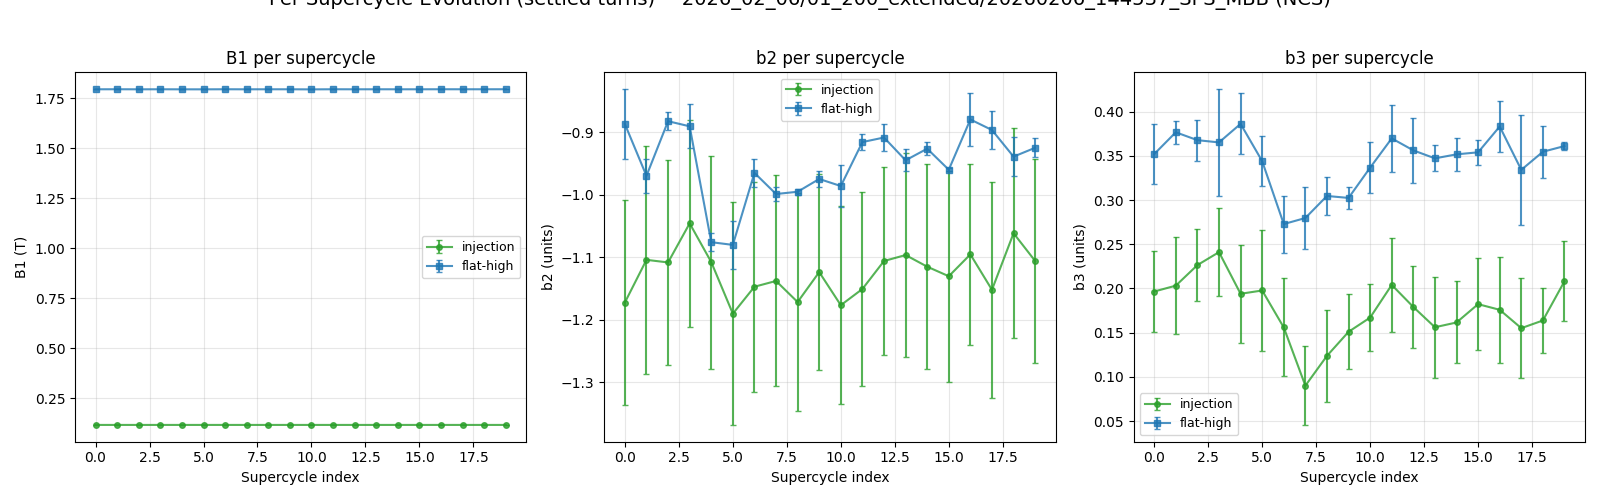


Stability across supercycles (settled turns):
    Quantity         Label       SC mean        SC std        SC p-p
-----------------------------------------------------------------
          B1     injection     +0.115633      0.000001      0.000006
          B1     flat-high     +1.793661      0.000164      0.000705
          b2     injection     -1.125140      0.037904      0.144579
          b2     flat-high     -0.950099      0.058092      0.200797
          b3     injection     +0.176577      0.034803      0.151042
          b3     flat-high     +0.344935      0.031998      0.113318


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col_name, ylabel) in zip(axes, [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]):
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")[col_name].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, alpha=0.8, label=lab)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)

axes[0].set_title("B1 per supercycle")
axes[1].set_title("b2 per supercycle")
axes[2].set_title("b3 per supercycle")

fig.suptitle(f"Per-Supercycle Evolution (settled turns) -- {SESSION} ({SEGMENT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nStability across supercycles (settled turns):")
print(f"{'Quantity':>12s}  {'Label':>12s}  {'SC mean':>12s}  {'SC std':>12s}  {'SC p-p':>12s}")
print("-" * 65)
for col_name, label, unit in [("B1_T", "B1", "T"), ("b2_units", "b2", "units"), ("b3_units", "b3", "units")]:
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_means = sub.groupby("sc_idx")[col_name].mean()
            print(f"{label:>12s}  {lab:>12s}  {sc_means.mean():+12.6f}  "
                  f"{sc_means.std():12.6f}  {sc_means.max()-sc_means.min():12.6f}")

---
## 13. Summary & Export

In [15]:
print("=" * 70)
print(f"SPS MBB DIPOLE -- {SEGMENT} STREAMING SUPERCYCLE ANALYSIS (200 GeV Extended)")
print("=" * 70)

print(f"\nMeasurement  : {SESSION}")
print(f"Segment      : {SEGMENT}")
print(f"Kn file      : {KN_PATH.name} (cross-session)")
print(f"Options      : {OPTIONS}")
print(f"cel/fed      : {diag.recommendation}")

print(f"\n--- Data Summary ---")
print(f"Total turns   : {n_turns}")
print(f"Plateau turns : {is_plateau.sum()}")
print(f"Injection     : {(turn_label == 'injection').sum()} turns, {len(inj_groups)} supercycles")
print(f"Flat-high     : {(turn_label == 'flat-high').sum()} turns, {len(fh_groups)} groups")

print(f"\n--- Settled Turns Summary ---")
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
    if len(sub) > 0:
        tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1e3)
        print(f"  {lab:12s}: N={len(sub):4d}, I={sub['I_mean_A'].mean():.1f} A, "
              f"B1={sub['B1_T'].mean():+.6f} T, "
              f"b2={sub['b2_units'].mean():+.3f}, b3={sub['b3_units'].mean():+.3f} units, "
              f"TF={tf:.4f} T/kA")

SPS MBB DIPOLE -- NCS STREAMING SUPERCYCLE ANALYSIS (200 GeV Extended)

Measurement  : 2026_02_06/01_200_extended/20260206_144537_SPS_MBB
Segment      : NCS
Kn file      : Kn_values_Seg_Main_A_AC.txt (cross-session)
Options      : ('dri', 'rot')
cel/fed      : UNSAFE

--- Data Summary ---
Total turns   : 1061
Plateau turns : 599
Injection     : 488 turns, 20 supercycles
Flat-high     : 74 turns, 20 groups

--- Settled Turns Summary ---
  injection   : N= 360, I=300.9 A, B1=+0.115633 T, b2=-1.125, b3=+0.177 units, TF=0.3843 T/kA
  flat-high   : N=  72, I=4814.5 A, B1=+1.793681 T, b2=-0.945, b3=+0.345 units, TF=0.3726 T/kA


In [16]:
out_dir = REPO_ROOT / "output" / "MBB/2026-02-06_supercycle" / "01_200_extended"
out_dir.mkdir(parents=True, exist_ok=True)

fname = f"MBB_{SEGMENT}_streaming_plateau.csv"
df.to_csv(out_dir / fname, index=False)
print(f"Wrote {out_dir / fname}  ({len(df)} rows)")

fname_s = f"MBB_{SEGMENT}_streaming_settled.csv"
df_settled.to_csv(out_dir / fname_s, index=False)
print(f"Wrote {out_dir / fname_s}  ({len(df_settled)} rows)")

print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\01_200_extended\MBB_NCS_streaming_plateau.csv  (562 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\01_200_extended\MBB_NCS_streaming_settled.csv  (432 rows)

Done.
